# Diffusion audit and scenarios where query choice matters

This is a **diagnostic notebook**, not another large benchmark. It audits the saved 12-scenario comparison, checks the inner sampler against one-dimensional numerical integration, and constructs three small candidate-pool designs for future controlled tests.

The production algorithm is NOT changed here. In particular, the first-sample estimator, hard-MIN loss, bounded box, projected inner states and unprojected outer states remain as specified. Post-hoc ensemble means below are diagnostics, not replacement experiment results.

All outputs are saved inline. To rerun the saved-run audit on a fresh checkout, run notebook 12 first so its JSON checkpoints exist. The conditional test and scenario construction use only small computations.

Main questions:
1. Did we implement the equations and query argmax correctly?
2. Are the finite-step numerical settings accurate enough?
3. Does the comparison isolate query selection from estimation?
4. Do our scenarios genuinely contain queries with very different information value?


In [1]:
from pathlib import Path
from dataclasses import replace
from itertools import product
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad
from IPython.display import display

root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src" / "invoptlab").exists())
sys.path.insert(0, str(root / "src"))
from invoptlab.active import (
    ActiveInverseEnvironment, ActiveScenarioConfig, AlgorithmObservation,
    FixedCardinalityDecisionSpace, PublicDecisionProblem,
    InverseLossTarget, GaussianSmoothedSampler, NestedLangevinConfig,
    angular_error_degrees, disagreement_score,
)
paths = sorted((root / "outputs" / "active" / "12_diffusion_comparison").glob("research-*--Diffusion.json"))
assert len(paths) == 12, "Run notebook 12 to generate the 12 comparison checkpoints."
saved = [json.loads(path.read_text()) for path in paths]
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})


## 1. Recompute the decisions and acquisition scores from the stored ensembles

For every saved round, this independently invokes the public MIN oracle on every candidate under every stored sample. It checks that the stored candidate scores match, that the chosen query is their argmax, and that the estimate is the first retained parameter. It does not rerun the learning algorithms.


In [2]:
audited_rounds = 0
maximum_score_difference = 0.0
for run in saved:
    environment = ActiveInverseEnvironment(ActiveScenarioConfig(**run["scenario"]))
    context = environment.algorithm_context()
    rng = np.random.default_rng(0)
    for record in run["records"]:
        d = record["action_diagnostics"]
        samples = np.asarray(d["theta_samples"])
        recomputed = []
        for index in d["candidate_indices"]:
            predictions = np.asarray([
                context.decision_problem.minimize(theta * context.query_candidates[index], rng)
                for theta in samples
            ])
            recomputed.append(disagreement_score(predictions))
        difference = float(np.max(np.abs(np.asarray(recomputed) - d["candidate_scores"])))
        maximum_score_difference = max(maximum_score_difference, difference)
        np.testing.assert_allclose(recomputed, d["candidate_scores"], atol=1e-12, rtol=0)
        assert d["candidate_index"] == d["candidate_indices"][int(np.argmax(recomputed))]
        np.testing.assert_array_equal(record["theta_hat_before"], samples[0])
        np.testing.assert_array_equal(record["theta_hat_after"], record["update_diagnostics"]["theta_samples"][0])
        audited_rounds += 1
print("Audited rounds:", audited_rounds)
print("Maximum acquisition-score discrepancy:", maximum_score_difference)
print("All stored first-sample estimates and query argmax choices agree with recomputation.")


Audited rounds: 96
Maximum acquisition-score discrepancy: 0.0
All stored first-sample estimates and query argmax choices agree with recomputation.


## 2. What the saved trajectories reveal

The comparison retained inner states at steps 17, 21, 25 and 29: only four states per conditional-mean estimate. These states are correlated. In a stationary unconstrained Gaussian conditional, the step-size/variance ratios used here imply a lag-four correlation around 0.81-0.85, giving only about 1.2-1.3 independent-sample equivalents for that four-state average. This is an illustrative calculation, NOT an ESS estimate for the actual constrained nonsmooth chains.

The projection rate counts proposals where at least one coordinate was projected; this grows with dimension and is not by itself proof of bias. The next section directly tests bias.


In [3]:
diagnostic_rows = []
for run in saved:
    records = run["records"]
    samples = np.asarray(records[-1]["update_diagnostics"]["theta_samples"])
    summaries = [s for record in records for s in record["update_diagnostics"]["trajectories"]]
    diagnostic_rows.append({
        "family": run["scenario"]["metadata"]["research_family"],
        "reported_first_sample_angle": run["evaluation"]["final_angular_error_degrees"],
        "posthoc_ensemble_mean_angle": angular_error_degrees(samples.mean(axis=0), run["true_theta"])[0],
        "unique_queries_of_8": len({r["action_diagnostics"]["candidate_index"] for r in records}),
        "rounds_with_tied_best_scores": sum(r["action_diagnostics"]["candidate_score_ties"] > 1 for r in records),
        "mean_any_coordinate_projection_rate": np.mean([s["inner_projection_rate"] for s in summaries]),
    })
diagnostics = pd.DataFrame(diagnostic_rows)
display(diagnostics.round(4))
for rho in [.96**4, .95**4]:
    m = 4
    effective = m / (1 + 2 * sum((1-k/m) * rho**k for k in range(1, m)))
    print(f"Gaussian illustration: lag-four correlation={rho:.3f}, four-state mean ESS={effective:.3f}.")
print("The post-hoc mean is NOT the specified estimator and has not been used to change the benchmark.")


,family,reported_first_sample_angle,posthoc_ensemble_mean_angle,unique_queries_of_8,rounds_with_tied_best_scores,mean_any_coordinate_projection_rate
0,cardinality-balanced-d20,19.4012,13.2342,5,1,0.8399
1,cardinality-parameter-noise-mild-d20,19.4012,13.2342,5,1,0.8399
2,cardinality-parameter-noise-moderate-d20,21.0330,13.8454,5,2,0.8374
3,cardinality-rare-informative-d20,21.8318,17.9640,4,2,0.8626
4,cardinality-small-margin-d20,27.0248,18.4154,6,6,0.8567
5,cardinality-sparse-queries-d20,34.7676,34.5308,8,3,0.8842
6,continuous-simplex-d10,51.4018,55.0639,6,4,0.6439
7,dag-path-d18,48.8079,39.8187,6,2,0.8139
8,dag-path-parameter-noise-moderate-d18,48.8079,39.8187,6,2,0.8139
9,geometry-cardinality-3d,3.2258,3.2040,5,4,0.2825


Gaussian illustration: lag-four correlation=0.849, four-state mean ESS=1.211.
Gaussian illustration: lag-four correlation=0.815, four-state mean ESS=1.268.
The post-hoc mean is NOT the specified estimator and has not been used to change the benchmark.


## 3. A direct numerical counterexample for the inner sampler settings

Use dimension 1, S=1, binary decisions, and eight observations Y=0. This is valid clean MIN data from a positive theta. With beta=20, the loss density is proportional to exp(-160 max(0,-z)) on [-1,1].

Fix outer u=-0.3 and tau=0.1. Numerical integration gives the conditional mean of
r(z|u) proportional to exp(-160 max(0,-z) - (u-z)^2/(2 tau)).
The production inner sampler should estimate this mean.

We compare the previous settings with (a) ten times more steps at the SAME step size and (b) ten times more steps with a TEN-TIMES-SMALLER step size. Each uses 64 independent seeds and retains four spaced states. This is a small one-dimensional diagnostic, not a new benchmark or a converged-sampler certification.


Reference conditional mean: 0.16414326643986885
Reference smoothed score: 4.641432664398688


,settings,steps,step_size,estimated_conditional_mean,reference_mean,bias,MC_standard_error_across_64_runs,smoothed_score_RMSE
0,Comparison settings,32,0.0050,0.403081,0.164143,0.238938,0.018123,2.788964
1,"More steps, same step size",320,0.0050,0.379776,0.164143,0.215633,0.016071,2.505389
2,"More steps, smaller step size",320,0.0005,0.167968,0.164143,0.003825,0.011982,0.951812


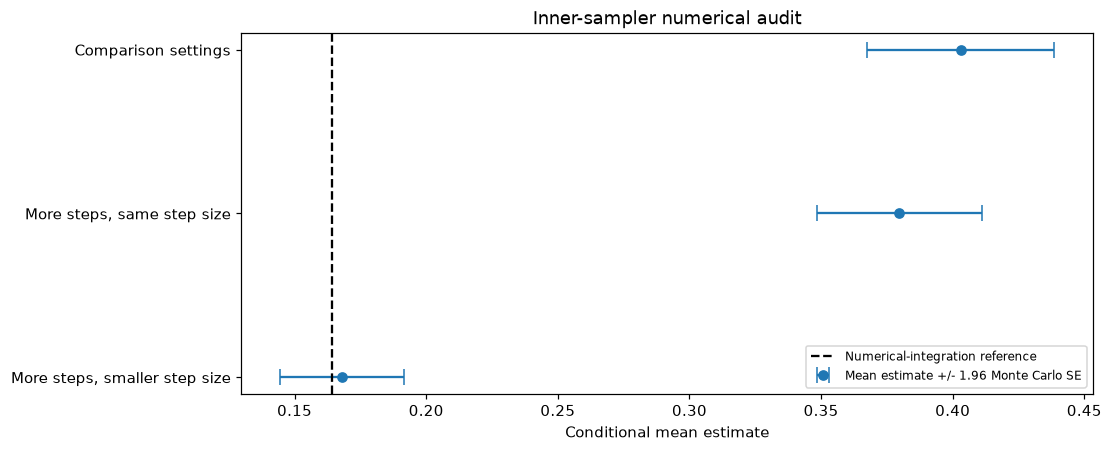

In [4]:
observations = [AlgorithmObservation(i + 1, np.ones(1), np.zeros(1)) for i in range(8)]
u, tau, beta = -0.3, 0.1, 20.0
weight = lambda z: np.exp(-160.0 * max(0.0, -z) - (u-z)**2 / (2*tau))
normalizer = quad(weight, -1, 1, points=[0], epsabs=1e-12, epsrel=1e-12)[0]
reference_mean = quad(lambda z: z*weight(z), -1, 1, points=[0], epsabs=1e-12, epsrel=1e-12)[0] / normalizer
reference_score = (reference_mean - u) / tau
print("Reference conditional mean:", reference_mean)
print("Reference smoothed score:", reference_score)

rows = []
for label, n, delta in [
    ("Comparison settings", 32, 0.005),
    ("More steps, same step size", 320, 0.005),
    ("More steps, smaller step size", 320, 0.0005),
]:
    config = NestedLangevinConfig(
        sampler="projected_langevin", point_estimate="first", query_tie_breaking="first", theta_samples=4,
        inner_steps=n, inner_burn_in=n//2, inner_thinning=n//8, record_chain_trace=False,
    )
    values = []
    for seed in range(64):
        target = InverseLossTarget(1, beta, lambda theta, s: (theta*s < 0).astype(float), observations)
        sampler = GaussianSmoothedSampler(target, config, np.random.default_rng(seed))
        values.append(sampler.run_inner_chain(np.array([u]), tau, delta).mean[0])
    values = np.asarray(values)
    rows.append({
        "settings": label, "steps": n, "step_size": delta,
        "estimated_conditional_mean": values.mean(), "reference_mean": reference_mean,
        "bias": values.mean() - reference_mean,
        "MC_standard_error_across_64_runs": values.std(ddof=1) / np.sqrt(len(values)),
        "smoothed_score_RMSE": np.sqrt(np.mean(((values-reference_mean)/tau)**2)),
    })
conditional_audit = pd.DataFrame(rows)
display(conditional_audit.round(6))
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
ax.errorbar(
    conditional_audit.estimated_conditional_mean, range(3),
    xerr=1.96*conditional_audit.MC_standard_error_across_64_runs, fmt="o", capsize=5,
    label="Mean estimate +/- 1.96 Monte Carlo SE",
)
ax.axvline(reference_mean, color="black", ls="--", label="Numerical-integration reference")
ax.set_yticks(range(3), conditional_audit.settings)
ax.set(xlabel="Conditional mean estimate", title="Inner-sampler numerical audit")
ax.invert_yaxis()
ax.legend(fontsize=8)
plt.show()


This counterexample shows that passing update-equation tests is not enough: the chosen finite step sizes can bias the conditional mean and thus the smoothed score. More iterations alone do not remove fixed-step discretization bias. Smaller steps with adequate runtime substantially reduce the bias in THIS check; they are not automatically adequate for every dimension, dataset or smoothing level.

The cumulative SUM loss gets steeper as observations accumulate, while the previous step sizes did not adapt to t. This is a numerical configuration problem allowed by the specification, not a swapped sign, incorrectly projected outer state, or use of the wrong estimate. No production settings are silently changed by this audit.

Projected Langevin and nonsmooth Langevin have convergence analyses under controlled assumptions and numerical conditions; those results do not certify arbitrary short nested chains. Background: [Bubeck, Eldan and Lehec](https://arxiv.org/abs/1507.02564), [Lehec](https://arxiv.org/abs/2101.10695).


## 4. Why “low-rank S” was not a sufficient information bottleneck

The observation normals are s * (y-x), not simply s. Multiplying by different decision differences can produce a much larger span than the query vectors themselves. The following rank-one query produces rank-three consistency normals. This does NOT imply full parameter identification; it disproves the assumption that the query rank alone bounds the normal rank.

A better information bottleneck is to make some coordinates exactly zero in all common queries, so those coordinates genuinely cannot influence the observed decisions.


In [5]:
query = np.ones(4) / 2
problem = PublicDecisionProblem(FixedCardinalityDecisionSpace(4, 2))
batch = problem.consistency_normals(
    query, np.array([1, 1, 0, 0]), None, np.ones(4), np.random.default_rng(0),
)
print("Rank of query matrix:", np.linalg.matrix_rank(query[None, :]))
print("Rank of resulting consistency normals:", np.linalg.matrix_rank(batch.normals))
assert np.linalg.matrix_rank(query[None, :]) == 1
assert np.linalg.matrix_rank(batch.normals) == 3


Rank of query matrix: 1
Rank of resulting consistency normals: 3


## 5. Three concrete small scenario designs

Keep F(theta,s,x)=theta dot (s*x), a MIN expert, no observation noise, and IID Gaussian parameter noise with sigma=0.02. Use a fixed T=12 for future experiments. These constructions define public candidate pools independently of the selected true parameter.

1. **Threshold localization (d=2).** X={e1,e2}, S(q)=(q,1)/sqrt(q^2+1). For positive true parameters, the choice reveals whether q is below or above theta2/theta1. Querying near the remaining uncertainty can act like noisy binary search; uniform queries often fall outside the remaining interval.
2. **Rare informative queries (d=2).** 95% of the candidates have q in [0.15,0.35], while 5% cover [0.5,1.75]. Once the coarse ratio range is learned, most queries repeat an already-predictable answer. A good committee should concentrate on the informative group. Evaluation must also include the informative range, not be dominated by the easy 95%.
3. **Missing-coordinate coverage (d=4).** X={e1,e2,e3,e4}. Each S has negative entries only at coordinate 1 and one other coordinate. For positive true parameters the decision compares that coordinate with the shared reference. 90% of candidates compare coordinates 1 and 2, 5% compare 1 and 3, and 5% compare 1 and 4. Unqueried coordinates are genuinely unobserved, while the shared reference connects all ratios and avoids an artificial independent-block scale ambiguity. Evaluate the three pair types equally.

The following cell constructs the actual query arrays and problem descriptions. These are scenario designs, not newly registered built-in benchmark families; feeding explicit candidate pools into the benchmark is a subsequent integration step. The current algorithms are not trained on these cases in this notebook.


In [6]:
def unit(v):
    return np.asarray(v, dtype=float) / np.linalg.norm(v)

def ratio_queries(q_values, dimension=2, other=1, negative=False):
    values = np.zeros((len(q_values), dimension))
    values[:, 0] = q_values
    values[:, other] = 1.0
    values /= np.linalg.norm(values, axis=1)[:, None]
    return -values if negative else values

rng = np.random.default_rng(17)
threshold_q = np.linspace(0.25, 2.25, 128)
rare_q = np.concatenate([np.linspace(0.15, 0.35, 380), np.linspace(0.5, 1.75, 20)])
rare_group = np.array(["redundant"]*380 + ["informative"]*20)
order = rng.permutation(len(rare_q))
rare_q, rare_group = rare_q[order], rare_group[order]
coverage_parts, coverage_groups = [], []
for other, count in [(1, 288), (2, 16), (3, 16)]:
    coverage_parts.append(ratio_queries(np.linspace(.25, 2.25, count), 4, other, negative=True))
    coverage_groups.extend([f"reference-vs-{other+1}"]*count)
coverage_queries = np.vstack(coverage_parts)
coverage_groups = np.asarray(coverage_groups)
order = rng.permutation(len(coverage_queries))
coverage_queries, coverage_groups = coverage_queries[order], coverage_groups[order]

scenario_designs = {
    "Threshold localization": {
        "dimension": 2, "X": np.eye(2), "candidates": ratio_queries(threshold_q),
        "theta_star": unit([1, 1.1]), "parameter_sigma": .02, "horizon": 12,
        "test_queries": ratio_queries(np.linspace(.25, 2.25, 96)),
        "group": np.array(["threshold"]*128),
    },
    "Rare informative queries": {
        "dimension": 2, "X": np.eye(2), "candidates": ratio_queries(rare_q),
        "theta_star": unit([1, 1.1]), "parameter_sigma": .02, "horizon": 12,
        "test_queries": ratio_queries(np.linspace(.5, 1.75, 96)),
        "group": rare_group,
    },
    "Missing-coordinate coverage": {
        "dimension": 4, "X": np.eye(4), "candidates": coverage_queries,
        "theta_star": unit([1, .7, 1.3, 1.7]), "parameter_sigma": .02, "horizon": 12,
        "test_queries": np.vstack([
            ratio_queries(np.linspace(.25, 2.25, 32), 4, other, negative=True)
            for other in (1, 2, 3)
        ]),
        "group": coverage_groups,
    },
}
display(pd.DataFrame([{
    "scenario": name, "dimension": d["dimension"],
    "candidates": len(d["candidates"]), "test_queries": len(d["test_queries"]),
    "parameter_sigma": d["parameter_sigma"], "future_T": d["horizon"],
} for name, d in scenario_designs.items()]))
for design in scenario_designs.values():
    np.testing.assert_allclose(np.linalg.norm(design["candidates"], axis=1), 1)


,scenario,dimension,candidates,test_queries,parameter_sigma,future_T
0,Threshold localization,2,128,96,0.02,12
1,Rare informative queries,2,400,96,0.02,12
2,Missing-coordinate coverage,4,320,96,0.02,12


## 6. Does the acquisition formula recognize these useful queries?

This is an **idealized committee diagnostic**, not a claim that our short-chain Diffusion sampler produced these hypotheses. The committees represent a possible stage after signs/coarse bounds have been learned. They are not priors imposed on the production algorithm.

For the first two designs, plausible ratios range from 0.5 to 1.75. For coverage, the reference/second-coordinate ratio is already known while the other two remain uncertain. We calculate the specified disagreement score exactly for these supplied hypotheses.


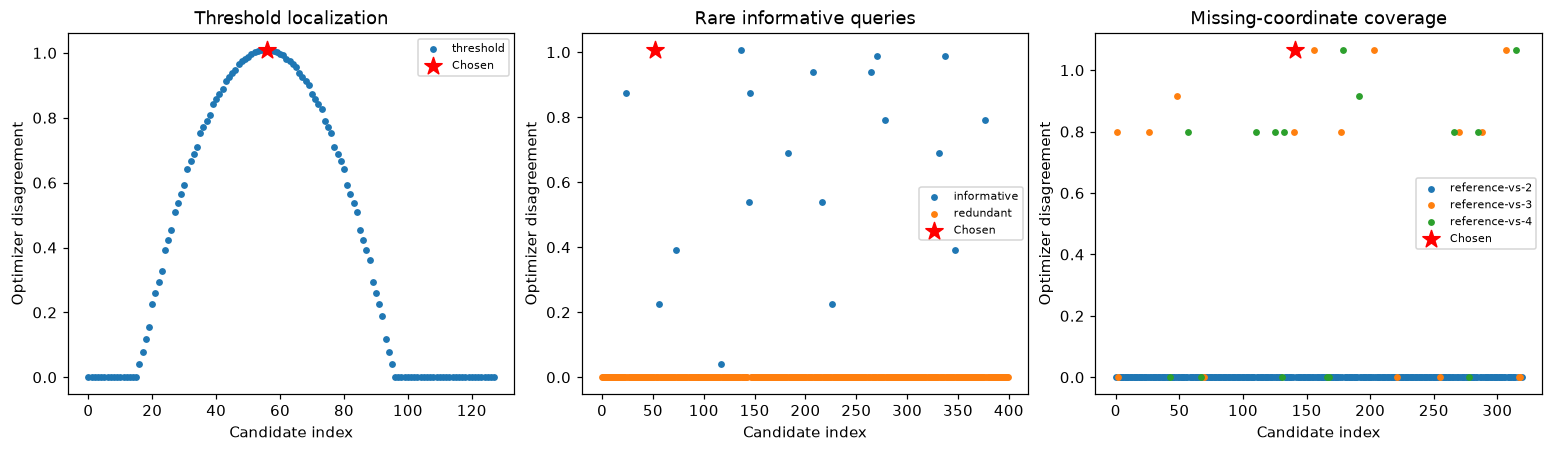

,scenario,chosen_group,positive_disagreement_fraction,selected_score
0,Threshold localization,threshold,0.6250,1.009901
1,Rare informative queries,informative,0.0475,1.007525
2,Missing-coordinate coverage,reference-vs-4,0.0625,1.066667


Rare-query design: random querying misses the 5% informative group in all 12 rounds with probability 54.0%.
Coverage design: random querying misses at least one rare coordinate group in 12 rounds with probability 79.8%.
These probabilities assume independent uniform draws with replacement, not adaptive querying.


In [7]:
def committee_scores(design, samples):
    scores = []
    for query in design["candidates"]:
        costs = samples * query
        decisions = design["X"][np.argmin(costs, axis=1)]
        scores.append(disagreement_score(decisions))
    return np.asarray(scores)

ratio_committee = np.asarray([unit([1, r]) for r in np.linspace(.5, 1.75, 101)])
coverage_committee = np.asarray([
    unit([1, .7, r2, r3]) for r2, r3 in product([.6, 1.05, 1.5, 1.95], repeat=2)
])
committees = [ratio_committee, ratio_committee, coverage_committee]
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
acquisition_rows = []
for ax, (name, design), committee in zip(axes, scenario_designs.items(), committees):
    scores = committee_scores(design, committee)
    chosen = int(np.argmax(scores))
    for group in np.unique(design["group"]):
        indices = np.flatnonzero(design["group"] == group)
        ax.scatter(indices, scores[indices], s=12, label=group)
    ax.scatter(chosen, scores[chosen], color="red", marker="*", s=140, label="Chosen")
    ax.set(title=name, xlabel="Candidate index", ylabel="Optimizer disagreement")
    ax.legend(fontsize=7)
    acquisition_rows.append({
        "scenario": name, "chosen_group": design["group"][chosen],
        "positive_disagreement_fraction": np.mean(scores > 1e-12),
        "selected_score": scores[chosen],
    })
    if name == "Rare informative queries":
        assert design["group"][chosen] == "informative"
    if name == "Missing-coordinate coverage":
        assert design["group"][chosen] != "reference-vs-2"
plt.show()
display(pd.DataFrame(acquisition_rows))
print(f"Rare-query design: random querying misses the 5% informative group in all 12 rounds with probability {0.95**12:.1%}.")
print(f"Coverage design: random querying misses at least one rare coordinate group in 12 rounds with probability {2*0.95**12 - 0.9**12:.1%}.")
print("These probabilities assume independent uniform draws with replacement, not adaptive querying.")


## Conclusions and next controlled experiment

- The saved query scores, argmax decisions and first-sample estimates agree with the implemented rule in all 96 audited rounds.
- A direct integration check exposes substantial inner-sampler numerical bias at the previous step size. Simply increasing the number of iterations at that same step size is insufficient in the counterexample.
- The first-sample estimator adds variance; averaging the saved ensemble often reduces angular error, but replacing the estimator would change the agreed algorithm and has NOT been done.
- Four parameter samples are a coarse representation of uncertainty in 10-20 dimensions. A noisy or biased committee can select poor queries even when the acquisition formula is implemented correctly.
- The loss target does not explicitly model Gaussian parameter-noise likelihood. With noise, L_t(0)=0 and positive homogeneity can favor smaller magnitudes. Removing hard-cone failure is not a guarantee of parameter recovery.
- The old comparison changed BOTH estimation and query selection. To isolate query selection, compare **the same sampler/first-sample estimator** with uniform random queries versus disagreement queries, keeping the incenter algorithm as an additional baseline.
- Keep the linear F. First use the small threshold, rare-query and coverage designs, with parameter noise and balanced meaningful held-out tests. Validate sampler accuracy before any larger study.
- No production algorithm, point-estimate convention, parameter domain, or old experiment output was modified by this audit.
